# 8.2 误差反向传播

> **课时**：2课时 | **难度**：⭐⭐⭐⭐ | **竞赛重要度**：⭐⭐⭐⭐⭐

## 📚 学习目标

1. 理解前向传播的逐层数学计算
2. 掌握损失函数的作用与常用形式
3. 深入理解链式法则与反向传播推导过程
4. 理解计算图的构建与使用
5. 能够用 numpy 从零实现前馈神经网络的前向传播与反向传播
6. 在 XOR 数据集上验证网络的学习能力

---

## 1. 前向传播的数学描述

### 1.1 网络结构

考虑一个两层（1个隐藏层）的全连接前馈神经网络：

$$\text{输入层}(n) \rightarrow \text{隐藏层}(m) \rightarrow \text{输出层}(k)$$

### 1.2 逐层计算

**第一步：隐藏层计算**

$$\mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}$$
$$\mathbf{a}^{(1)} = f^{(1)}(\mathbf{z}^{(1)})$$

**第二步：输出层计算**

$$\mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)}$$
$$\mathbf{a}^{(2)} = f^{(2)}(\mathbf{z}^{(2)}) = \hat{\mathbf{y}}$$

其中：
| 符号 | 含义 | 维度 |
|------|------|------|
| $\mathbf{x}$ | 输入向量 | $(n, 1)$ |
| $\mathbf{W}^{(1)}$ | 第一层权重 | $(m, n)$ |
| $\mathbf{b}^{(1)}$ | 第一层偏置 | $(m, 1)$ |
| $\mathbf{z}^{(1)}$ | 隐藏层加权输入 | $(m, 1)$ |
| $\mathbf{a}^{(1)}$ | 隐藏层激活输出 | $(m, 1)$ |
| $\mathbf{W}^{(2)}$ | 第二层权重 | $(k, m)$ |
| $\mathbf{b}^{(2)}$ | 第二层偏置 | $(k, 1)$ |
| $\hat{\mathbf{y}}$ | 预测输出 | $(k, 1)$ |

### 1.3 矩阵形式（批量计算）

对于 $N$ 个样本的批量前向传播：

$$\mathbf{Z}^{(1)} = \mathbf{X} \cdot \mathbf{W}^{(1)T} + \mathbf{b}^{(1)}$$
$$\mathbf{A}^{(1)} = f^{(1)}(\mathbf{Z}^{(1)})$$
$$\mathbf{Z}^{(2)} = \mathbf{A}^{(1)} \cdot \mathbf{W}^{(2)T} + \mathbf{b}^{(2)}$$
$$\hat{\mathbf{Y}} = f^{(2)}(\mathbf{Z}^{(2)})$$

> **维度对应**：$\mathbf{X}$ 为 $(N, n)$，$\mathbf{W}^{(1)}$ 为 $(m, n)$，则 $\mathbf{X} \cdot \mathbf{W}^{(1)T}$ 为 $(N, m)$。

---

## 2. 损失函数的作用

### 2.1 为什么需要损失函数？

损失函数衡量模型预测值 $\hat{y}$ 与真实值 $y$ 之间的差距，是优化目标。

### 2.2 常用损失函数

**均方误差（MSE）**——用于回归：

$$L = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

**二元交叉熵（Binary Cross-Entropy）**——用于二分类：

$$L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

**交叉熵（Categorical Cross-Entropy）**——用于多分类：

$$L = -\sum_{i=1}^{N}\sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$

### 2.3 损失函数与优化的关系

$$\mathbf{W}^* = \arg\min_{\mathbf{W}} L(\mathbf{W})$$

我们需要计算损失函数对每个参数的梯度：

$$\frac{\partial L}{\partial \mathbf{W}}, \quad \frac{\partial L}{\partial \mathbf{b}}$$

然后使用梯度下降更新参数。

---

## 3. 链式法则与反向传播推导

### 3.1 链式法则（Chain Rule）

链式法则是微积分中复合函数求导的基本法则：

$$\frac{\partial L}{\partial w_{ij}^{(1)}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial a_j^{(1)}} \cdot \frac{\partial a_j^{(1)}}{\partial z_j^{(1)}} \cdot \frac{\partial z_j^{(1)}}{\partial w_{ij}^{(1)}}$$

### 3.2 两层网络的完整反向传播推导

**记号定义**：
- $\delta^{(2)} = \frac{\partial L}{\partial \mathbf{z}^{(2)}}$：输出层的误差信号
- $\delta^{(1)} = \frac{\partial L}{\partial \mathbf{z}^{(1)}}$：隐藏层的误差信号

**输出层梯度**：

$$\delta^{(2)} = \frac{\partial L}{\partial \mathbf{z}^{(2)}} = \frac{\partial L}{\partial \hat{\mathbf{y}}} \odot f'^{(2)}(\mathbf{z}^{(2)})$$

$$\frac{\partial L}{\partial \mathbf{W}^{(2)}} = \delta^{(2)} \cdot (\mathbf{a}^{(1)})^T$$

$$\frac{\partial L}{\partial \mathbf{b}^{(2)}} = \delta^{(2)}$$

**隐藏层梯度**（关键！）：

$$\delta^{(1)} = \left(\mathbf{W}^{(2)T} \delta^{(2)}\right) \odot f'^{(1)}(\mathbf{z}^{(1)})$$

$$\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \delta^{(1)} \cdot \mathbf{x}^T$$

$$\frac{\partial L}{\partial \mathbf{b}^{(1)}} = \delta^{(1)}$$

其中 $\odot$ 表示 **Hadamard 乘积**（逐元素乘法）。

### 3.3 反向传播的核心思想

> **误差信号从输出层向输入层"反向传播"**：输出层的误差 $\delta^{(2)}$ 通过权重矩阵的转置 $\mathbf{W}^{(2)T}$ 传递到隐藏层，再乘以激活函数的导数，得到隐藏层的误差 $\delta^{(1)}$。

这就是"反向传播"（Backpropagation）名称的由来！

### 3.4 梯度计算总结表

| 参数 | 梯度公式 |
|------|---------|
| $\mathbf{W}^{(2)}$ | $\delta^{(2)} \cdot (\mathbf{a}^{(1)})^T$ |
| $\mathbf{b}^{(2)}$ | $\delta^{(2)}$ |
| $\mathbf{W}^{(1)}$ | $\delta^{(1)} \cdot \mathbf{x}^T$ |
| $\mathbf{b}^{(1)}$ | $\delta^{(1)}$ |
| $\delta^{(2)}$ | $\frac{\partial L}{\partial \hat{\mathbf{y}}} \odot f'^{(2)}(\mathbf{z}^{(2)})$ |
| $\delta^{(1)}$ | $\left(\mathbf{W}^{(2)T} \delta^{(2)}\right) \odot f'^{(1)}(\mathbf{z}^{(1)})$ |

---

## 4. 计算图

### 4.1 什么是计算图？

计算图将前向传播的每一步操作表示为图中的节点，边表示数据的流向。

### 4.2 XOR 问题的计算图示例

```
        x₁ ──┐
              ├──→ z₁ = w₁₁·x₁ + w₁₂·x₂ + b₁ ──→ a₁ = σ(z₁) ──┐
        x₂ ──┘                                                      ├──→ z₂ = w₂₁·a₁ + w₂₂·a₂ + b₂ ──→ ŷ = σ(z₂) ──→ L(ŷ, y)
                                                                      │
        x₁ ──┐                                                       │
              ├──→ z₁' = w₂₁·x₁ + w₂₂·x₂ + b₂' ──→ a₂ = σ(z₁') ──┘
        x₂ ──┘
```

### 4.3 反向传播在计算图上的理解

前向传播：从左到右计算每个节点的值。
反向传播：从右到左，利用链式法则计算每个节点的梯度。

---

## 5. 反向传播的直观理解

### 5.1 梯度如何从输出层传到输入层？

1. **输出层**：计算损失对输出层加权输入的梯度 $\delta^{(2)}$
2. **权重转置传播**：将 $\delta^{(2)}$ 通过权重矩阵的转置 $\mathbf{W}^{(2)T}$ "投影"回隐藏层
3. **激活函数修正**：乘以激活函数的导数 $f'^{(1)}(\mathbf{z}^{(1)})$，得到 $\delta^{(1)}$
4. **重复**：对更深的网络，继续向更前面的层传播

### 5.2 类比理解

想象一个工厂流水线：
- **前向传播**：原材料（输入）经过一道道工序（各层）变成成品（输出）
- **损失函数**：质检部门评估成品与标准的差距
- **反向传播**：质检结果从最后一道工序反馈到第一道工序，告诉每道工序如何调整

> 如果某道工序的激活函数导数接近0（梯度消失），那质检反馈就无法传到前面的工序。

---

## 6. 竞赛考点总结

| 考点 | 重要程度 |
|------|---------|
| 前向传播的逐层公式 | ⭐⭐⭐⭐⭐ |
| 损失函数（MSE, 交叉熵） | ⭐⭐⭐⭐⭐ |
| 链式法则推导反向传播 | ⭐⭐⭐⭐⭐ |
| $\delta^{(l)}$ 的计算 | ⭐⭐⭐⭐⭐ |
| 计算图的概念 | ⭐⭐⭐⭐ |
| 梯度消失的直观理解 | ⭐⭐⭐⭐ |


## 7. 代码实战：从零实现两层前馈神经网络

### 7.1 定义网络结构与激活函数

In [27]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'STSong', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 激活函数及其导数
# ============================================

def sigmoid(z):
    """Sigmoid 激活函数"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    """Sigmoid 的导数 (基于 a 而不是 z)"""
    a = sigmoid(z)
    return a * (1 - a)

def tanh_activation(z):
    """Tanh 激活函数"""
    return np.tanh(z)

def tanh_derivative(a):
    """Tanh 的导数 (基于 a)"""
    return 1 - a ** 2


print("=" * 60)
print("激活函数已定义")
print("=" * 60)
print("  sigmoid(z) = 1 / (1 + exp(-z))")
print("  sigmoid'(a) = a * (1 - a)")
print("  tanh(z) = (exp(z) - exp(-z)) / (exp(z) + exp(-z))")
print("  tanh'(a) = 1 - a²")

激活函数已定义
  sigmoid(z) = 1 / (1 + exp(-z))
  sigmoid'(a) = a * (1 - a)
  tanh(z) = (exp(z) - exp(-z)) / (exp(z) + exp(-z))
  tanh'(a) = 1 - a²


### 7.2 实现两层前馈神经网络类

In [28]:
class TwoLayerNN:
    """
    两层全连接前馈神经网络 (从零实现)
    
    结构: 输入层(n) -> 隐藏层(m) -> 输出层(1)
    激活函数: 隐藏层使用 sigmoid, 输出层使用 sigmoid
    损失函数: 均方误差 (MSE)
    优化: 梯度下降
    """
    
    def __init__(self, input_dim, hidden_dim, output_dim=1, lr=0.5):
        self.n = input_dim    # 输入维度
        self.m = hidden_dim   # 隐藏层维度
        self.k = output_dim   # 输出维度
        self.lr = lr          # 学习率
        
        # 初始化权重 (Xavier 初始化)
        self.W1 = np.random.randn(self.m, self.n) * np.sqrt(2.0 / self.n)
        self.b1 = np.zeros((1, self.m))
        self.W2 = np.random.randn(self.k, self.m) * np.sqrt(2.0 / self.m)
        self.b2 = np.zeros((1, self.k))
        
        # 存储中间值（前向传播时保存，反向传播时使用）
        self.cache = {}
        self.loss_history = []
    
    def forward(self, X):
        """前向传播"""
        # X: (N, n) 或 (n,)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        
        # 隐藏层
        Z1 = X @ self.W1.T + self.b1    # (N, m)
        A1 = sigmoid(Z1)                # (N, m)
        
        # 输出层
        Z2 = A1 @ self.W2.T + self.b2   # (N, k)
        A2 = sigmoid(Z2)                # (N, k)
        
        # 缓存（保存反向传播需要的数据）
        self.cache = {
            'X': X, 'Z1': Z1, 'A1': A1, 
            'Z2': Z2, 'A2': A2
        }
        
        return A2
    
    def compute_loss(self, y_pred, y_true):
        """计算 MSE 损失"""
        if y_true.ndim == 1:
            y_true = y_true.reshape(-1, 1)
        loss = np.mean((y_pred - y_true) ** 2)
        return loss
    
    def backward(self, y_true):
        """反向传播"""
        if y_true.ndim == 1:
            y_true = y_true.reshape(-1, 1)
        
        X = self.cache['X']
        A1 = self.cache['A1']
        A2 = self.cache['A2']
        Z1 = self.cache['Z1']
        Z2 = self.cache['Z2']  # 修复：从缓存获取Z2
        
        N = X.shape[0]
        
        # ========== 输出层梯度 ==========
        # dL/dA2 = 2*(A2 - Y) / N  (MSE 的导数)
        dA2 = 2 * (A2 - y_true) / N
        # δ² = dL/dZ2 = dL/dA2 * sigmoid'(Z2)
        dZ2 = dA2 * sigmoid_derivative(Z2)
        
        # dL/dW2 = δ² · A1^T
        dW2 = dZ2.T @ A1    # (k, N) @ (N, m) -> (k, m)
        db2 = np.sum(dZ2, axis=0, keepdims=True)  # (1, k)
        
        # ========== 隐藏层梯度 ==========
        # δ¹ = (W2^T · δ²) * sigmoid'(Z1)
        dA1 = dZ2 @ self.W2    # (N, k) @ (k, m) -> (N, m)
        dZ1 = dA1 * sigmoid_derivative(Z1)
        
        # dL/dW1 = δ¹ · X^T
        dW1 = dZ1.T @ X        # (m, N) @ (N, n) -> (m, n)
        db1 = np.sum(dZ1, axis=0, keepdims=True)  # (1, m)
        
        # ========== 更新参数 ==========
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2        # (1, k) - (1, k)
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1        # (1, m) - (1, m)
        
        return dW1, db1, dW2, db2
    
    def train(self, X, y, epochs=10000, verbose=True):
        """训练网络"""
        for epoch in range(epochs):
            # 前向传播
            y_pred = self.forward(X)
            
            # 计算损失
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            
            # 反向传播
            self.backward(y)
            
            # 打印进度
            if verbose and (epoch % 2000 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:>5d} | Loss: {loss:.6f}")
            
            # 提前停止
            if loss < 1e-6:
                print(f"✓ Epoch {epoch:>5d} | Loss: {loss:.8f} (收敛！)")
                break
    
    def predict(self, X):
        """预测"""
        return self.forward(X)


print("=" * 60)
print("两层前馈神经网络类已定义")
print("=" * 60)
print("  结构: 输入 -> 隐藏层(sigmoid) -> 输出(sigmoid)")
print("  损失: MSE")
print("  优化: 随机梯度下降")

两层前馈神经网络类已定义
  结构: 输入 -> 隐藏层(sigmoid) -> 输出(sigmoid)
  损失: MSE
  优化: 随机梯度下降


### 7.3 在 XOR 数据集上训练

In [29]:
# ============================================
# XOR 数据集
# ============================================

X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=np.float64)
y_xor = np.array([[0],
                   [1],
                   [1],
                   [0]], dtype=np.float64)

print("XOR 数据集:")
print("x₁  x₂ | y")
print("--------|---")
for xi, yi in zip(X_xor, y_xor):
    print(f" {xi[0]:.0f}  {xi[1]:.0f} | {yi[0]:.0f}")

# ============================================
# 创建并训练网络
# ============================================
print("\n" + "=" * 60)
print("训练两层神经网络解决 XOR 问题")
print("=" * 60)

np.random.seed(42)  # 固定随机种子
nn = TwoLayerNN(input_dim=2, hidden_dim=4, output_dim=1, lr=2.0)
nn.train(X_xor, y_xor, epochs=10000)

# ============================================
# 验证结果
# ============================================
print("\n训练后的预测结果:")
print("-" * 50)
print(f"{'输入':>8} | {'原始输出':>10} | {'四舍五入':>8} | {'真实':>4} | {'状态':>6}")
print("-" * 50)
y_pred = nn.predict(X_xor)
for xi, pred, yi in zip(X_xor, y_pred, y_xor):
    rounded = 1 if pred[0] > 0.5 else 0
    status = "✓" if rounded == yi[0] else "✗"
    print(f"{str(xi):>8} | {pred[0]:>10.6f} | {rounded:>8} | {int(yi[0]):>4} | {status:>6}")

accuracy = np.mean((y_pred > 0.5).astype(int) == y_xor)
print(f"\n准确率: {accuracy*100:.0f}%")

XOR 数据集:
x₁  x₂ | y
--------|---
 0  0 | 0
 0  1 | 1
 1  0 | 1
 1  1 | 0

训练两层神经网络解决 XOR 问题
Epoch     0 | Loss: 0.255405
Epoch  2000 | Loss: 0.000842
Epoch  4000 | Loss: 0.000343
Epoch  6000 | Loss: 0.000211
Epoch  8000 | Loss: 0.000151
Epoch  9999 | Loss: 0.000117

训练后的预测结果:
--------------------------------------------------
      输入 |       原始输出 |     四舍五入 |   真实 |     状态
--------------------------------------------------
 [0. 0.] |   0.012309 |        0 |    0 |      ✓
 [0. 1.] |   0.989319 |        1 |    1 |      ✓
 [1. 0.] |   0.990030 |        1 |    1 |      ✓
 [1. 1.] |   0.010205 |        0 |    0 |      ✓

准确率: 100%


### 7.4 可视化训练过程与决策边界

C:\Users\Terry\AppData\Local\Temp\ipykernel_4516\1289297694.py:34: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(xi[0], xi[1], c=c, marker=m, s=200,


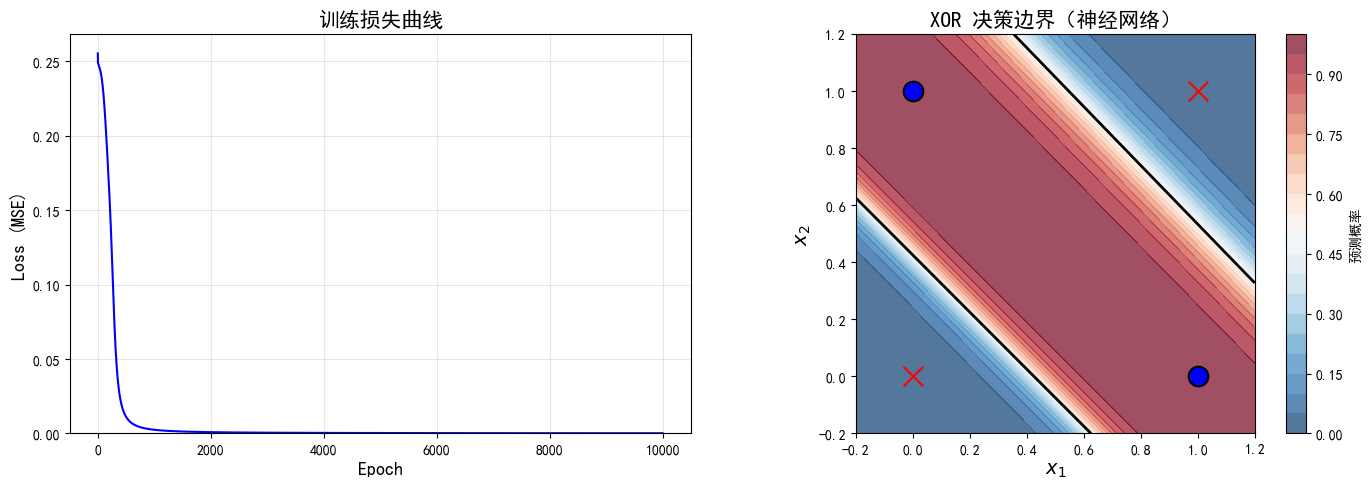

左图：损失随训练轮数的变化（期望逐渐下降）
右图：神经网络的决策边界——注意它是非线性的弯曲边界


In [30]:
# ============================================
# 可视化损失曲线
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失曲线
ax1 = axes[0]
ax1.plot(nn.loss_history, 'b-', linewidth=1.5)
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Loss (MSE)', fontsize=13)
ax1.set_title('训练损失曲线', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# 右图：决策边界
ax2 = axes[1]

# 生成网格点
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# 预测网格点
Z = nn.predict(grid).reshape(xx.shape)

# 绘制等高线
contour = ax2.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
ax2.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# 绘制数据点
colors = ['blue' if yi == 1 else 'red' for yi in y_xor.ravel()]
markers = ['o' if yi == 1 else 'x' for yi in y_xor.ravel()]
for xi, yi, c, m in zip(X_xor, y_xor, colors, markers):
    ax2.scatter(xi[0], xi[1], c=c, marker=m, s=200, 
               edgecolors='black', linewidth=1.5, zorder=5)

ax2.set_xlabel('$x_1$', fontsize=14)
ax2.set_ylabel('$x_2$', fontsize=14)
ax2.set_title('XOR 决策边界（神经网络）', fontsize=15, fontweight='bold')
plt.colorbar(contour, ax=ax2, label='预测概率')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("左图：损失随训练轮数的变化（期望逐渐下降）")
print("右图：神经网络的决策边界——注意它是非线性的弯曲边界")

### 7.5 手动计算反向传播（验证理解）

让我们对单个样本手动计算一步反向传播，验证代码的正确性。

In [31]:
# ============================================
# 手动验证反向传播（单步）
# ============================================

print("=" * 60)
print("手动反向传播验证")
print("=" * 60)

# 设定简单参数以便手动计算
np.random.seed(0)
W1_test = np.array([[0.5, -0.3],   # 2个隐藏神经元, 2个输入
                    [0.2, 0.8],
                    [-0.6, 0.1],
                    [0.4, -0.5]])
b1_test = np.array([[0.1], [0.2], [-0.1], [0.3]])
W2_test = np.array([[0.7, -0.4, 0.3, 0.6]])  # 1个输出, 4个隐藏
b2_test = np.array([[0.1]])

# 手动前向传播
x = np.array([[0, 1]])  # XOR: (0,1) -> 1
y = np.array([[1]])

print(f"\n输入: x = {x}")
print(f"真实标签: y = {y}")

# 隐藏层
Z1 = x @ W1_test.T + b1_test.T
print(f"\n--- 前向传播 ---")
print(f"Z1 = x·W1^T + b1 = {Z1}")
A1 = sigmoid(Z1)
print(f"A1 = sigmoid(Z1) = {A1}")

# 输出层
Z2 = A1 @ W2_test.T + b2_test.T
print(f"Z2 = A1·W2^T + b2 = {Z2}")
A2 = sigmoid(Z2)
print(f"A2 = sigmoid(Z2) = {A2}")
print(f"\n预测输出: ŷ = {A2[0,0]:.6f}")

# 手动反向传播
print(f"\n--- 反向传播 ---")
N = 1

# 输出层
dA2 = 2 * (A2 - y) / N
print(f"dL/dA2 = 2(ŷ-y)/N = {dA2}")
dZ2 = dA2 * sigmoid_derivative(Z2)
print(f"δ² = dL/dZ2 = {dZ2}")

dW2 = dZ2.T @ A1
db2 = dZ2
print(f"dL/dW2 = δ²·A1^T = {dW2}")
print(f"dL/db2 = δ² = {db2}")

# 隐藏层
dA1 = dZ2 @ W2_test
dZ1 = dA1 * sigmoid_derivative(Z1)
print(f"\ndL/dA1 = δ²·W2 = {dA1}")
print(f"δ¹ = dL/dZ1 = {dZ1}")

dW1 = dZ1.T @ x
db1 = dZ1
print(f"dL/dW1 = δ¹·x^T = {dW1}")
print(f"dL/db1 = δ¹ = {db1}")

print(f"\n{'='*60}")
print("手动反向传播计算完成！")
print("可以看到梯度从输出层（δ²）通过权重矩阵传到隐藏层（δ¹）")

手动反向传播验证

输入: x = [[0 1]]
真实标签: y = [[1]]

--- 前向传播 ---
Z1 = x·W1^T + b1 = [[-0.2  1.   0.  -0.2]]
A1 = sigmoid(Z1) = [[0.450166   0.73105858 0.5        0.450166  ]]
Z2 = A1·W2^T + b2 = [[0.54279237]]
A2 = sigmoid(Z2) = [[0.63246176]]

预测输出: ŷ = 0.632462

--- 反向传播 ---
dL/dA2 = 2(ŷ-y)/N = [[-0.73507649]]
δ² = dL/dZ2 = [[-0.17087138]]
dL/dW2 = δ²·A1^T = [[-0.07692049 -0.12491699 -0.08543569 -0.07692049]]
dL/db2 = δ² = [[-0.17087138]]

dL/dA1 = δ²·W2 = [[-0.11960997  0.06834855 -0.05126142 -0.10252283]]
δ¹ = dL/dZ1 = [[-0.02960545  0.01343814 -0.01281535 -0.0253761 ]]
dL/dW1 = δ¹·x^T = [[ 0.         -0.02960545]
 [ 0.          0.01343814]
 [ 0.         -0.01281535]
 [ 0.         -0.0253761 ]]
dL/db1 = δ¹ = [[-0.02960545  0.01343814 -0.01281535 -0.0253761 ]]

手动反向传播计算完成！
可以看到梯度从输出层（δ²）通过权重矩阵传到隐藏层（δ¹）


### 7.6 可视化梯度传播过程

C:\Users\Terry\AppData\Local\Temp\ipykernel_4516\919402743.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(grad_names, rotation=15, ha='right')


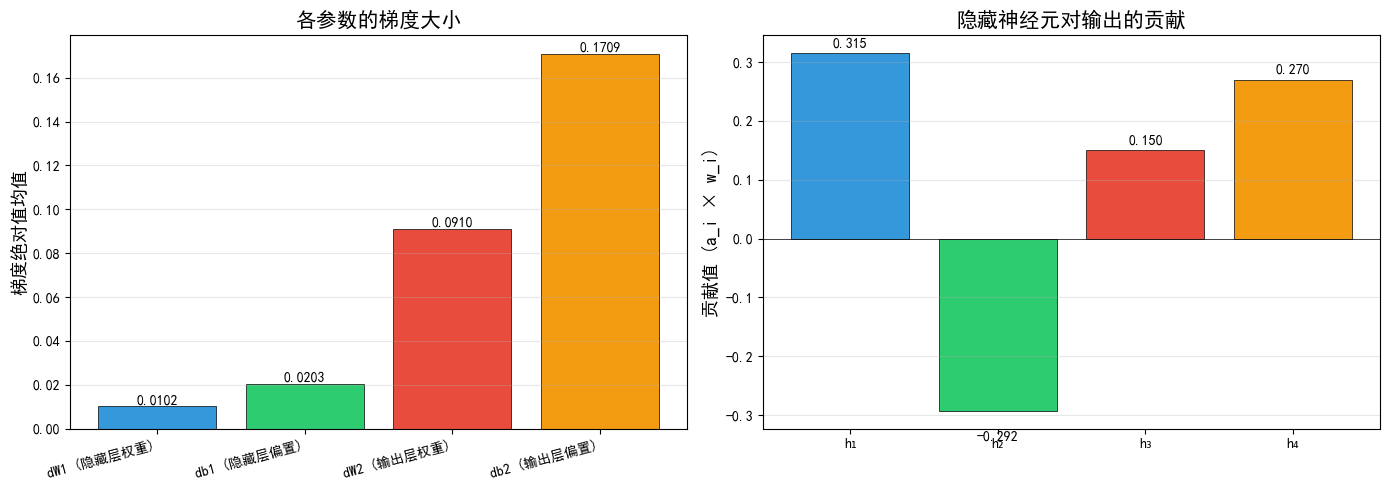

左图：对比隐藏层和输出层参数的梯度大小
右图：每个隐藏神经元对最终输出的加权贡献


In [32]:
# ============================================
# 可视化梯度大小在层数间变化
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各参数梯度大小
ax1 = axes[0]
grad_names = ['dW1 (隐藏层权重)', 'db1 (隐藏层偏置)', 'dW2 (输出层权重)', 'db2 (输出层偏置)']
grad_mags = [np.abs(dW1).mean(), np.abs(db1).mean(), np.abs(dW2).mean(), np.abs(db2).mean()]
colors_grad = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = ax1.bar(grad_names, grad_mags, color=colors_grad, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('梯度绝对值均值', fontsize=13)
ax1.set_title('各参数的梯度大小', fontsize=15, fontweight='bold')
ax1.set_xticklabels(grad_names, rotation=15, ha='right')
for bar, val in zip(bars, grad_mags):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 右图：各隐藏神经元对输出的贡献
ax2 = axes[1]
neurons = ['h₁', 'h₂', 'h₃', 'h₄']

# 确保 contributions 的 shape 是 (4,)
# W2_test 对应隐藏层到输出层权重，可能为 (1, 4) 或 (4, 1)
# A1 为 (1, 4) 或 (4, 1)
# 贡献应为每个隐藏神经元的 a_i * w_i，维度数需匹配
# 假设 W2_test shape = (1, 4), A1 shape = (1, 4)
w = W2_test.flatten()    # (4,)
a = A1.flatten()         # (4,)
contributions = a * w    # (4,)

ax2.bar(neurons, contributions, color=colors_grad[:4], edgecolor='black', linewidth=0.5)
ax2.set_ylabel('贡献值 (a_i × w_i)', fontsize=13)
ax2.set_title('隐藏神经元对输出的贡献', fontsize=15, fontweight='bold')
ax2.axhline(y=0, color='black', linewidth=0.5)
for i, (n, v) in enumerate(zip(neurons, contributions)):
    ax2.text(i, v + 0.01 if v > 0 else v - 0.05, f'{v:.3f}', ha='center', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("左图：对比隐藏层和输出层参数的梯度大小")
print("右图：每个隐藏神经元对最终输出的加权贡献")

---

## 📝 练习题

### 题目 1：前向传播计算

**Q1.** 一个神经网络：输入 $x = [1, 2]$，隐藏层权重 $\mathbf{W}^{(1)} = \begin{bmatrix} 0.5 & 0.3 \\ 0.1 & 0.4 \end{bmatrix}$，偏置 $\mathbf{b}^{(1)} = [0.1, -0.1]$。隐藏层使用 sigmoid 激活函数。请计算隐藏层输出 $\mathbf{a}^{(1)}$。

<details>
<summary>点击查看答案</summary>

$$\mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)} = \begin{bmatrix} 0.5 \times 1 + 0.3 \times 2 + 0.1 \\ 0.1 \times 1 + 0.4 \times 2 + (-0.1) \end{bmatrix} = \begin{bmatrix} 1.2 \\ 0.8 \end{bmatrix}$$

$$\mathbf{a}^{(1)} = \sigma(\mathbf{z}^{(1)}) = \begin{bmatrix} \sigma(1.2) \\ \sigma(0.8) \end{bmatrix} = \begin{bmatrix} 0.7685 \\ 0.6899 \end{bmatrix}$$

</details>

### 题目 2：反向传播推导

**Q2.** 写出两层网络中隐藏层误差信号 $\delta^{(1)}$ 的完整计算公式，解释每个部分的含义。

<details>
<summary>点击查看答案</summary>

$$\delta^{(1)} = \left(\mathbf{W}^{(2)T} \delta^{(2)}\right) \odot f'^{(1)}(\mathbf{z}^{(1)})$$

- $\delta^{(2)}$：输出层的误差信号
- $\mathbf{W}^{(2)T}$：输出层权重的转置，将输出层误差"投影"回隐藏层
- $\odot$：Hadamard 乘积（逐元素乘法）
- $f'^{(1)}(\mathbf{z}^{(1)})$：隐藏层激活函数的导数，调节误差信号的大小

</details>

### 题目 3：梯度消失

**Q3.** 如果网络中使用 sigmoid 激活函数，为什么深层网络容易出现梯度消失？请从数学角度解释。

<details>
<summary>点击查看答案</summary>

Sigmoid 函数的导数最大值为 0.25（在 $z=0$ 时取到）。在反向传播中：

$$\delta^{(l)} = \left(\mathbf{W}^{(l+1)T} \delta^{(l+1)}\right) \odot f'(\mathbf{z}^{(l)})$$

当多层网络的梯度逐层传播时，每经过一层都会乘以一个不超过 0.25 的因子。对于 $L$ 层网络，梯度会乘以 $0.25^L$。当 $L$ 很大时，这个值趋近于 0，导致梯度消失。

</details>

### 题目 4：编程题

**Q4.** 修改 `TwoLayerNN` 类，将隐藏层激活函数从 sigmoid 改为 tanh，观察在 XOR 问题上的训练效果是否更好。

<details>
<summary>点击查看参考答案</summary>

```python
class TwoLayerNN_Tanh(TwoLayerNN):
    def forward(self, X):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        Z1 = X @ self.W1.T + self.b1.T
        A1 = np.tanh(Z1)  # 使用 tanh
        Z2 = A1 @ self.W2.T + self.b2.T
        A2 = sigmoid(Z2)
        self.cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
        return A2
    
    def backward(self, y_true):
        # ... 类似，但 tanh 导数为 1 - a²
        pass

nn_tanh = TwoLayerNN_Tanh(input_dim=2, hidden_dim=4, lr=1.0)
nn_tanh.train(X_xor, y_xor, epochs=10000)
```

tanh 通常比 sigmoid 收敛更快，因为其导数最大值为 1（sigmoid 只有 0.25）。

</details>

### 题目 5：竞赛真题风格

**Q5.** 关于反向传播算法，以下说法正确的是（ ）

A. 反向传播从输入层开始计算梯度，向输出层传播
B. 反向传播的核心是链式法则
C. 反向传播只能用于两层网络
D. 反向传播不需要保存前向传播的中间结果

<details>
<summary>点击查看答案</summary>

**答案：B**

- A 错误：反向传播从输出层开始，向输入层传播（"反向"）
- B 正确：反向传播的本质就是链式法则的系统性应用
- C 错误：反向传播适用于任意深度的前馈网络
- D 错误：反向传播需要缓存前向传播的中间值（$\mathbf{z}^{(l)}, \mathbf{a}^{(l)}$）

</details>
